## Naive Bayes from Scratch (for Categorical Data)

In this notebook worksheet you will learn **how to build your own classifier** that behaves like an sklearn estimator.

By the end of this notebook you should be able to:

- **Understand** how a simple classifier class with `fit`, `predict`, and `predict_proba` methods works.
- **Implement** a Naive Bayes classifier for **categorical features only**.
- **Make your estimator sklearn-compatible** by following the sklearn API (we will inherit from `sklearn.base.BaseEstimator` and `ClassifierMixin`, so tools like `clone` and `cross_val_score` can work with your estimator).
- Build your own version of `cross_val_score` function to perform cross validation.
- **Tune** the smoothing parameter \( \alpha \) using **cross-validation**.

We will proceed in the following order:

1. A simple example to explain what classes/objects are, and the naming conventions used by sklearn: **MajorityClassClassifier** (baseline model)
2. Understanding the classifier interface (`fit`, `predict`, `predict_proba`)
3. Building a **Naive Bayes classifier for categorical data** (you need to complete all the places marked with TODOs)
4. You will implement your own **Cross-validation** to choose the best smoothing parameter \( \alpha \)

Run each code cell in order and read the comments carefully—they are written to explain what each line is doing.

**If you get stuck:** you may temporarily use the sklearn backups (see the import cell) to keep moving. Using a backup earns **0 points** for that section, but it lets you complete later parts of the notebook.


In [16]:
# Run this cell to import all required libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, ClassifierMixin, clone

# Optional: only needed if you choose to use the sklearn NB backup
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.naive_bayes import MultinomialNB

RANDOM_STATE = 42  # use this for all random_state arguments (reproducibility)

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import fetch_openml

# BACKUP (NB): If you are unable to implement MyCategoricalNaiveBayes, you can temporarily use an sklearn pipeline
# that *does* work with string/categorical columns:
#
# def make_sklearn_nb(alpha=1.0):
#     return make_pipeline(
#         OneHotEncoder(handle_unknown="ignore"),
#         MultinomialNB(alpha=alpha),
#     )
#
# Then, wherever you would write MyCategoricalNaiveBayes(alpha=alpha), write make_sklearn_nb(alpha=alpha).
# (Using this backup is only to let you finish later sections; it earns 0 points for the NB section.)

# BACKUP (CV): If you are unable to implement my_cross_val_score, you may use sklearn's cross_val_score:
# from sklearn.model_selection import cross_val_score
# Example:
#   scores = cross_val_score(MyCategoricalNaiveBayes(alpha=alpha), X_train, y_train, cv=skf, scoring="accuracy")
# NOTE: sklearn's CV utilities require estimators to be cloneable; our classes inherit from BaseEstimator so this works.


## 1. A Simple Baseline: MajorityClassClassifier (3 pts)

We will start with a very simple classifier that you could easily write yourself: a **majority class classifier**.

- During training (`fit`), it looks at the training labels and finds the **most frequent class**.
- During prediction (`predict`), it **always predicts that class** for every new example.
- It also has a `predict_proba` method, which returns the **same class-probability vector** for every example.

This example illustrates the basic structure of a classifier class that behaves like an sklearn estimator.

---

### Quick intro: Classes and objects (if this is your first time)

- **Class** = a blueprint or template. It defines what kind of thing we have and what it can do.
- **Object** = one specific instance created from that class.

**Example:** `Car` is a class (the idea of a car). `my_subaru` and `your_tesla` are two different **objects** of that class—each is a concrete car with its own state (e.g. speed, fuel).

When you write a class in Python:

1. **`__init__(self, ...)`** — the **constructor**
   - **When is it called?** Automatically when you create an object: e.g. `my_subaru = Car(speed=0)`.
   - **What does it do?** It runs once per object to set up **initial state** (attributes). For example, a `Car` might set `self.speed = 0` and `self.fuel = 100`. Anything you assign to `self.` here (or in other methods) is stored on that specific object.

2. **Other methods** (e.g. `drive()`, `fit()`, `predict()`) — define what the object can do. They use `self` to read or update that object’s attributes.

**Why do some names end with an underscore (e.g. `classes_`, `majority_class_`)?**

- This follows **sklearn’s convention**:
  - **No trailing `_`**: things set in `__init__` that the *user* chooses (e.g. `alpha` in Naive Bayes). These are **hyperparameters** or configuration.
  - **Trailing `_`**: attributes that are **learned from data** (set during `fit()`). For example `classes_`, `majority_class_`, and `class_probabilities_` are filled in when we call `fit(X_train, y_train)`, not when we create the object.

So when you see `self.classes_ = None` in `__init__`, we are only *reserving* a name; the real value is assigned later in `fit()`. That way we can tell at a glance: “this was estimated from the data” (has `_`) vs “this was set by the user when creating the model” (no `_`).


In [17]:
# Optional: minimal class example (run this to see class vs object, __init__, and a method)
class Car:
    def __init__(self, speed=0):
        # This runs automatically when we create a Car, e.g. Car(speed=60)
        self.speed = speed   # no trailing _: set by the user at creation time

    def drive(self, distance):
        # Method: uses self to read/change this object's state
        print(f"Driving {distance} km at speed {self.speed}")
        return distance / max(self.speed, 1)  # time in hours

my_subaru = Car(speed=60)   # __init__ runs here with speed=60
your_tesla = Car(speed=120) # a different object, different speed

print("Subaru speed:", my_subaru.speed)
print("Tesla speed:", your_tesla.speed)
my_subaru.drive(120)  # 120 km at 60 km/h

Subaru speed: 60
Tesla speed: 120
Driving 120 km at speed 60


2.0

In [18]:
class MajorityClassClassifier(BaseEstimator, ClassifierMixin):
    """
    A very simple baseline classifier.

    - During `fit`, it looks at the training labels y and finds the most frequent class.
    - During `predict`, it always predicts that majority class for every observation.
    - During `predict_proba`, it outputs the same class-probability vector for every observation.
    """

    def __init__(self):
        # __init__ runs once when you create an object: e.g. model = MajorityClassClassifier()
        # Below we only reserve names; the real values are filled in during fit() (learned from data).
        # Trailing underscore _ = "estimated from data" (sklearn convention); no _ = user-set (e.g. alpha).
        self.classes_ = None           # will hold the list of class labels (set in fit)
        self.majority_class_ = None   # will hold the most frequent class (set in fit)
        self.class_probabilities_ = None  # will hold P(each class) (set in fit)

    def fit(self, X, y):
        """
        Learn from the training data.

        Parameters
        ----------
        X : array-like, shape (n_samples, n_features)
            Feature matrix (we will not actually use X in this simple model).
        y : array-like, shape (n_samples,)
            Target labels.
        """
        # Convert y to a pandas Series so we can use convenient functions like value_counts.
        y_series = pd.Series(y)

        # value_counts() returns counts of each class, sorted by count.
        class_counts = y_series.value_counts()

        # The index of the first element is the majority class.
        self.majority_class_ = class_counts.idxmax()

        # Store the classes in a fixed order so we can produce probabilities in this order.
        self.classes_ = class_counts.index.to_list()

        # Convert counts to probabilities by dividing by the total number of samples.
        self.class_probabilities_ = (class_counts / class_counts.sum()).reindex(self.classes_).values

        return self  # return self so we can chain methods like in sklearn

    def predict(self, X):
        """
        Predict class labels for the given feature matrix X.

        We ignore X and always return the majority class.
        """
        # The number of rows in X tells us how many predictions we need to make.
        n_samples = len(X)

        # Create a list/array filled with the majority class, one entry per sample.
        return np.array([self.majority_class_] * n_samples)

    def predict_proba(self, X):
        """
        Predict class probabilities for the given feature matrix X.

        Returns an array of shape (n_samples, n_classes), where each row is the
        same vector of class probabilities.
        """
        n_samples = len(X)

        # Repeat the learned class probability vector for each sample.
        proba_matrix = np.tile(self.class_probabilities_, (n_samples, 1))

        return proba_matrix


In [19]:
# Let's create a small toy dataset with categorical features only.
# In practice you can replace this with any real dataset with categorical features.

data = pd.DataFrame({
    "Color": ["Red", "Red", "Blue", "Green", "Green", "Green", "Blue", "Red", "Green", "Blue", "Red", "Green"],
    "Shape": ["Circle", "Square", "Triangle", "Circle", "Triangle", "Square", "Circle", "Circle", "Square", "Triangle", "Circle", "Triangle"],
    "Class": ["A", "A", "B", "A", "B", "B", "A", "A", "A", "A", "B", "B"]
})

X = data[["Color", "Shape"]]
y = data["Class"]

# Split into train and test sets (this should look familiar from sklearn usage).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

# Create and fit the majority-class baseline model.
baseline_model = MajorityClassClassifier()
baseline_model.fit(X_train, y_train)

# Use the model to make predictions.
y_pred = baseline_model.predict(X_test)
y_proba = baseline_model.predict_proba(X_test)

print("Predicted labels:", y_pred)
print("Predicted probabilities:\n", y_proba)

print("\nAccuracy on test set:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))


Predicted labels: ['A' 'A' 'A']
Predicted probabilities:
 [[0.55555556 0.44444444]
 [0.55555556 0.44444444]
 [0.55555556 0.44444444]]

Accuracy on test set: 0.6666666666666666

Classification report:
               precision    recall  f1-score   support

           A       0.67      1.00      0.80         2
           B       0.00      0.00      0.00         1

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 2. From Baseline to Naive Bayes (39 pts)

Now we will build a **Naive Bayes classifier** for **categorical features**. The key idea is:

- We estimate **class prior probabilities** \( P(y) \).
- For each feature and each possible categorical value, we estimate **conditional probabilities**
  \( P(x_j = v \mid y = c) \).
- For a new observation, we use the **Naive Bayes assumption** that features are conditionally independent given the class:
  \[
  P(y = c \mid x_1, \dots, x_d) \propto P(y = c) \prod_{j=1}^d P(x_j \mid y = c).
  \]

We will work in **log-space** to avoid numerical underflow and to turn products into sums:

\[
  \log P(y = c \mid x) \propto \log P(y = c) + \sum_{j=1}^d \log P(x_j \mid y = c).
\]

Below is a scaffolded implementation of a `MyCategoricalNaiveBayes` class. Your job is to **fill in the TODO parts** using the hints in the comments. Once you have implemented all the TODOs in `MyCategoricalNaiveBayes`, you should be able to use it just like an sklearn classifier:

```python
model = MyCategoricalNaiveBayes(alpha=1.0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
```

In [20]:
class MyCategoricalNaiveBayes(BaseEstimator, ClassifierMixin):
    """
    Naive Bayes classifier for categorical features.

    This class is intentionally written with TODOs for you to complete.
    It follows the sklearn-style interface: fit, predict, predict_proba.
    """

    def __init__(self, alpha=1.0):
        """
        Parameters
        ----------
        alpha : float
            Smoothing parameter (Laplace / additive smoothing).
            alpha = 0 means no smoothing (can lead to zero probabilities).
            alpha > 0 adds alpha to each count before normalizing.
        """
        self.alpha = alpha
        self.classes_ = None
        # We will store log P(y) here, one value per class.
        self.class_log_prior_ = None
        # We will store log P(x_j = value | y) here.
        # Suggested structure:
        #   self.feature_log_prob_ is a dict:
        #       key   = column name (feature)
        #       value = pandas DataFrame with:
        #                 rows    = class labels
        #                 columns = possible categorical values for that feature
        self.feature_log_prob_ = {}
        # (Optional but recommended) store the categories seen for each feature during fit.
        # This is useful for handling unseen categories at prediction time.
        self.feature_categories_ = {}

    def fit(self, X, y):
        """
        Fit the Naive Bayes model from training data.

        Parameters
        ----------
        X : pandas DataFrame of shape (n_samples, n_features)
            All features should be categorical (object or category dtype).
        y : array-like or pandas Series of shape (n_samples,)
            Target labels.
        """
        # Convert y to a pandas Series to use value_counts and align indexes easily.
        y_series = pd.Series(y)
        self.classes_ = y_series.unique()

        # TODO 1: Compute class prior probabilities P(y).
        # - Use value_counts() on y_series to get counts per class.
        class_counts = (
          y_series
          .value_counts()
          .reindex(self.classes_, fill_value=0)
        )

        # - Apply additive smoothing if you want (alpha on class counts).
        alpha = getattr(self, "alpha", 0)
        smoothed_counts = class_counts + alpha

        # - Divide by the total number of samples to get probabilities.
        smoothed_total = len(y_series) + alpha * len(self.classes_)

        # - Take the natural log (np.log) and store in self.class_log_prior_
        self.class_log_prior_ = np.log(smoothed_counts / smoothed_total)

        # Hint: use y_series.value_counts().reindex(self.classes_, fill_value=0)
        # so that the order matches self.classes_.

        # TODO 2: For each feature column in X, compute conditional probabilities
        # P(x_j = value | y = class) with additive smoothing.

        # Initialize dictionary to store feature log probabilities
        self.feature_log_prob_ = {}
        self.feature_categories_ = {}

        # For each column:
        #   - Get all possible categories for that column (e.g., list(X[col].unique())).
        for col in X.columns:
            categories = list(X[col].astype(str).unique())

        #     IMPORTANT (CV pitfall): In cross-validation, a category value might appear in a validation fold
        #     that did NOT appear in that fold's training data. If you do a direct lookup like
        #     log_prob_table.loc[class_label, category_value], that can raise a KeyError.
        #
        #     Two simple ways to avoid crashes:
        #       (1) Add a special "__UNK__" category during fit (include it in the columns of your table),
        #           and in prediction map any unseen value to "__UNK__".
        #       (2) Or: if a value is unseen, just add 0 (or a constant) to all classes for that feature
        #           so it provides no evidence but also does not crash.

            if "__UNK__" not in categories:
                categories.append("__UNK__")

            self.feature_categories_[col] = categories

        #   - Use pd.crosstab to build a contingency table: it counts how often each
        #     (class, category) pair occurs (rows = class labels, columns = feature values).
            counts = pd.crosstab(y_series, X[col].astype(str))

        #   - Reindex so rows and columns include all classes and all categories.
        #     Starter:
        #     counts = counts.reindex(index=...)
        #     counts = counts.reindex(columns=...)
            counts = counts.reindex(index=self.classes_, fill_value=0)
            counts = counts.reindex(columns=categories, fill_value=0)

        #   - Apply additive smoothing: add self.alpha to every cell.
            smoothed = counts + alpha

        #   - Normalize each row so that row sums to 1 (use .div(row_sums, axis=0)).
            row_sums = smoothed.sum(axis=1)
            probs = smoothed.div(row_sums, axis=0)
        #   - Take np.log of the resulting probabilities.
            log_probs = np.log(probs)

        #   - Store the resulting DataFrame in self.feature_log_prob_[col].
            self.feature_log_prob_[col] = log_probs

        # Hints:
        #   smoothed = counts + self.alpha
        #   row_sums = smoothed.sum(axis=1)
        #   probs = smoothed.div(row_sums, axis=0)
        #   log_probs = np.log(probs)

        # After implementing the above, return self to allow chaining.
        return self

    def _joint_log_likelihood(self, X):
        """
        Compute the joint log-likelihood for each class for each sample.

        For each sample i and class c, we want:
            log P(y = c) + sum over features j of log P(x_ij | y = c)

        Returns
        -------
        joint_log_likelihood : numpy array of shape (n_samples, n_classes)
        """
        # TODO 3: Implement the core Naive Bayes formula in log-space.

        # Steps:
        #   - Get the number of rows (samples) in X : n_samples = X.shape[0]
        n_samples = X.shape[0]
        n_classes = len(self.classes_)

        #   - Start with a matrix of shape (n_samples, n_classes)
        #     where each row is initialized with self.class_log_prior_.
        #     np.tile(A, reps) repeats array A to form a new array; e.g.
        #     np.tile([0.1, 0.2], (3, 1)) gives a 3x2 matrix with each row [0.1, 0.2].
        #     Hint: use np.tile or broadcasting.
        joint_log_likelihood = np.tile(self.class_log_prior_.values, (n_samples, 1))

        #   - For each feature column:
        #       * Look up the log-probability for the observed category value
        #         (If the value is unseen, use "__UNK__" if you added it, or otherwise handle it
        #          so you do not crash with a KeyError.)
        #         for each sample and each class.
        #         (Use the DataFrame self.feature_log_prob_[col]
        #          and .loc[class_label, category_value].)
        #       * Add these log-probabilities to the matrix.
        # Hints:
        #   - You may find it easier to loop over classes and/or rows at first.
        #   - Start with a simple (even if not super efficient) implementation.
        for col in X.columns:
          col_values = X[col].astype(str)

          for i in range(n_samples):
              value = col_values.iloc[i]
              if value not in self.feature_log_prob_[col].columns:
                  value = "__UNK__"
              for class_index, class_label in enumerate(self.classes_):
                  joint_log_likelihood[i, class_index] += (
                      self.feature_log_prob_[col]
                      .loc[class_label, value]
                  )

        # Return the completed joint_log_likelihood matrix.
        return joint_log_likelihood

        raise NotImplementedError("_joint_log_likelihood is not implemented yet.")

    def predict_proba(self, X):
        """
        Predict class probabilities for each sample in X.

        Returns
        -------
        proba : numpy array of shape (n_samples, n_classes)
        """
        # TODO 4: Use _joint_log_likelihood to get log-likelihoods.
        log_likelihood = self._joint_log_likelihood(X)

        #   - Subtract the max log-likelihood per row for numerical stability
        #     (this does not change the predicted class).
        log_likelihood -= log_likelihood.max(axis=1, keepdims=True)

        #   - Exponentiate to get unnormalized probabilities (np.exp).
        likelihood = np.exp(log_likelihood)

        #   - Normalize each row so the probabilities sum to 1.
        proba = likelihood / likelihood.sum(axis=1, keepdims=True)

        # Hints:
        #   log_likelihood = self._joint_log_likelihood(X)
        #   log_likelihood -= log_likelihood.max(axis=1, keepdims=True)
        #   likelihood = np.exp(log_likelihood)
        #   proba = likelihood / likelihood.sum(axis=1, keepdims=True)
        #
        #   keepdims=True is useful here: it keeps the reduced dimension so the result
        #   has shape (n_samples, 1) instead of (n_samples,). That way row-wise
        #   subtraction and division broadcast correctly against the (n_samples, n_classes) array.

        return proba

        raise NotImplementedError("predict_proba is not implemented yet.")

    def predict(self, X):
        """
        Predict the most likely class for each sample in X.
        """
        # TODO 5: Use predict_proba to get class probabilities
        # and then take the class with the highest probability.
        #
        # Hint:
        #   proba = self.predict_proba(X)
        #   class_indices = np.argmax(proba, axis=1)
        #   return np.array(self.classes_)[class_indices]
        proba = self.predict_proba(X)
        class_indices = np.argmax(proba, axis=1)
        return np.array(self.classes_)[class_indices]

        raise NotImplementedError("predict is not implemented yet.")

# BACKUP (NB): sklearn's CategoricalNB expects *integer-encoded* categories,
# so it is NOT a drop-in replacement for string columns. If you need a working sklearn backup,
# use a Pipeline with OneHotEncoder + MultinomialNB (see the import cell for make_sklearn_nb).


### Quick sanity checks (run after you finish the TODOs)

Before moving on to cross-validation, run the cell below. It checks a few things that should be true for a correct implementation:

- Class prior probabilities sum to 1.
- For each feature, the conditional probabilities for each class sum to 1.
- `predict_proba` returns rows that sum to 1.

If you get a `NotImplementedError`, you still have TODOs to complete. If you get a `KeyError`, it is likely an **unseen category** issue (see the hints in TODO 2/3).


In [21]:
# Sanity checks (run after you implement the TODOs in MyCategoricalNaiveBayes)

try:
    nb_check = MyCategoricalNaiveBayes(alpha=1.0).fit(X_train, y_train)

    # 1) Priors should sum to 1 (in probability space).
    priors_sum = np.exp(nb_check.class_log_prior_).sum()
    print("Sum of class priors:", priors_sum)

    # 2) Each feature's conditional probabilities should sum to 1 for each class.
    for col, log_table in nb_check.feature_log_prob_.items():
        row_sums = np.exp(log_table).sum(axis=1)
        print(f"\nFeature '{col}' row sums (should be 1 for each class):")
        print(row_sums)

    # 3) predict_proba rows should sum to 1.
    proba = nb_check.predict_proba(X_test)
    print("\nFirst few predict_proba row sums (should all be 1):")
    print(proba.sum(axis=1)[:5])

except NotImplementedError as e:
    print("NotImplementedError:", e)
    print("Finish the TODOs in MyCategoricalNaiveBayes, then re-run this cell.")


Sum of class priors: 1.0

Feature 'Color' row sums (should be 1 for each class):
Class
A    1.0
B    1.0
dtype: float64

Feature 'Shape' row sums (should be 1 for each class):
Class
A    1.0
B    1.0
dtype: float64

First few predict_proba row sums (should all be 1):
[1. 1. 1.]


## 3. Cross-Validation for the Smoothing Parameter \( \alpha \) (17 pts)

You will now **implement your own simplified version of `cross_val_score`** and then use it to choose a good value of the smoothing parameter \( \alpha \).

The idea is to write a function (e.g. `my_cross_val_score`) that:

- Takes an **estimator instance** (like `MajorityClassClassifier()` or `MyCategoricalNaiveBayes(alpha=1.0)` — or even an sklearn estimator like `DecisionTreeClassifier()`),
- Takes the data `X`, `y`, and a cross-validation splitter like `StratifiedKFold`,
- Internally loops over folds, fits the estimator on the training part, evaluates it on the validation part, and
- Returns the list/array of validation scores.

Because our estimators inherit from `BaseEstimator`, you can also pass them to sklearn's `cross_val_score` if you want to sanity-check your results.

We will do this in two steps:

1. Implement `my_cross_val_score`.
2. Use `my_cross_val_score` to scan over different values of \( \alpha \) for `MyCategoricalNaiveBayes` (and optionally compare to `MajorityClassClassifier`).

**Important:** The code below will only work **after** you have implemented all the TODO methods in `MyCategoricalNaiveBayes`.


In [22]:
def my_cross_val_score(estimator, X, y, cv):
    """Very simple version of sklearn's cross_val_score.

    Parameters
    ----------
    estimator : classifier instance
        A classifier that has fit(X, y) and predict(X) methods,
        e.g. MyCategoricalNaiveBayes(alpha=1.0).
        Tip: use clone(estimator) inside the loop to get a fresh estimator each fold (like sklearn).
    X : pandas DataFrame, shape (n_samples, n_features)
    y : pandas Series or array-like, shape (n_samples,)
    cv : an object with a split(X, y) method, e.g. StratifiedKFold

    Returns
    -------
    scores : numpy array of shape (n_splits,)
        One score (accuracy) per fold.
    """

    scores = []

    # Ensure y is a pandas Series so that y.iloc[...] works even if y was passed as a numpy array.
    y = pd.Series(np.asarray(y), index=X.index)


    # TODO: Implement the cross-validation loop.
    # For each (train_idx, val_idx) pair from cv.split(X, y):
    for train_idx, val_idx in cv.split(X, y):

    #   1. Split X and y into train and validation using .iloc[train_idx] and .iloc[val_idx].
        X_train_fold = X.iloc[train_idx]
        X_val = X.iloc[val_idx]
        y_train_fold = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

    #   2. Fit the estimator on the training data for this fold.
        est_fold = clone(estimator)
        est_fold.fit(X_train_fold, y_train_fold)

    #   3. Predict on the validation data.
        y_pred = est_fold.predict(X_val)

    #   4. Compute accuracy using accuracy_score(y_val, y_val_pred).
    #   5. Append the accuracy to scores.
        scores.append(accuracy_score(y_val, y_pred))

    # Hint:
    #   for train_idx, val_idx in cv.split(X, y):
    #       X_train_fold = X.iloc[train_idx]
    #       X_val = X.iloc[val_idx]
    #       y_train_fold = y.iloc[train_idx]
    #       y_val = y.iloc[val_idx]
    #       est_fold = clone(estimator)  # fresh estimator each fold (like sklearn)
    #       est_fold.fit(X_train_fold, y_train_fold)
    #       y_val_pred = est_fold.predict(X_val)
    #       ...

    return np.array(scores)  # scores will be filled once you implement the loop.

# BACKUP: If you were not able to implement my_cross_val_score, replace it with sklearn's cross_val_score:
#   from sklearn.model_selection import cross_val_score
#   In the alpha loop below, use: scores = cross_val_score(MyCategoricalNaiveBayes(alpha=alpha), X_train, y_train, cv=skf, scoring='accuracy')


In [23]:
# Hyperparameter tuning for alpha using stratified K-fold cross-validation
# on the TRAINING set only (so the test set is never used for tuning).

# Choose some candidate alpha values to try.
alpha_values = [0.001, 0.1, 0.5, 1.0, 2.0, 5.0]

# Create a StratifiedKFold object to get train/validation index splits.
# Use: n_splits=3, shuffle=True, random_state=RANDOM_STATE
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

results = []

for alpha in alpha_values:
    # Create an estimator instance for this alpha; pass it to my_cross_val_score.
    # CV is run on X_train, y_train only (not on the full X, y).
    estimator = MyCategoricalNaiveBayes(alpha=alpha)
    scores = my_cross_val_score(estimator, X_train, y_train, cv=skf)

    mean_acc = scores.mean()
    results.append((alpha, mean_acc))
    print(f"alpha = {alpha:>4}: mean CV accuracy = {mean_acc:.3f}")

# Find the alpha with the best mean accuracy.
best_alpha, best_acc = max(results, key=lambda x: x[1])
print(f"\nBest alpha based on CV: {best_alpha} (mean accuracy = {best_acc:.3f})")

# Optional: you can also evaluate the MajorityClassClassifier with the same function:
# baseline_scores = my_cross_val_score(MajorityClassClassifier(), X_train, y_train, cv=skf)
# print("\nBaseline majority-class mean accuracy:", baseline_scores.mean())


alpha = 0.001: mean CV accuracy = 0.556
alpha =  0.1: mean CV accuracy = 0.556
alpha =  0.5: mean CV accuracy = 0.444
alpha =  1.0: mean CV accuracy = 0.556
alpha =  2.0: mean CV accuracy = 0.556
alpha =  5.0: mean CV accuracy = 0.556

Best alpha based on CV: 0.001 (mean accuracy = 0.556)


## 4. ROC AUC Analysis (Binary Classification) (5 pts)

Often we care not just about accuracy, but about how well a model ranks positive examples above negative ones.
The **ROC AUC** (Area Under the Receiver Operating Characteristic Curve) summarizes this.

We will assume a **binary classification** setting with a "positive" class (e.g., class `"B"` in our toy example).
To compute ROC AUC we need:

- The **true binary labels** (1 for positive class, 0 for all other classes).
- The **predicted probabilities for the positive class** (from `predict_proba`).

Then we can call `roc_auc_score(y_true_binary, y_score_for_positive_class)`.

The code below shows how to do this with your `MyCategoricalNaiveBayes` model.
You can adapt it for other datasets and other positive classes.

In [24]:
# Example: ROC AUC for MyCategoricalNaiveBayes on the toy dataset (binary classification)

# Choose which class should be treated as the "positive" class.
positive_class = "B"  # change this depending on your dataset

# Make sure your MyCategoricalNaiveBayes implementation is complete and fitted.
# Here we use the best_alpha found via cross-validation above.
nb_model = MyCategoricalNaiveBayes(alpha=best_alpha)
nb_model.fit(X_train, y_train)

# Get predicted probabilities on the test set.
proba_test = nb_model.predict_proba(X_test)

# Find the index of the positive class in nb_model.classes_.
pos_idx = list(nb_model.classes_).index(positive_class)

# y_true_binary: 1 for positive class, 0 for others.
y_true_binary = (y_test == positive_class).astype(int)

# y_score: predicted probability for the positive class.
y_score = proba_test[:, pos_idx]

# Compute ROC AUC.
roc_auc = roc_auc_score(y_true_binary, y_score)
print(f"ROC AUC for positive class '{positive_class}': {roc_auc:.3f}")

ROC AUC for positive class 'B': 0.500


## 5. Car Evaluation Dataset: Naive Bayes vs Decision Tree (13 pts)

To see your `MyCategoricalNaiveBayes` in action on a **real categorical dataset**, we will use the **Car Evaluation** dataset from UCI (available via `fetch_openml`).

- All features are **categorical** (buying price, maintenance, doors, persons, lug_boot, safety).
- The target `class` has 4 categories: `unacc`, `acc`, `good`, `vgood`.

We will:

1. Load the Car Evaluation dataset into a pandas DataFrame.
2. Split it into a train and test set.
3. For different **training set sizes** (e.g., 10%, 20%, ..., 80% of the training data):
   - Train your `MyCategoricalNaiveBayes`.
   - Train a `DecisionTreeClassifier` from sklearn.
   - Evaluate both on the **same fixed test set**.
4. Compare how their test accuracy changes as the amount of training data increases.

This gives you an empirical way to see the **bias–variance tradeoff**: Naive Bayes is usually higher bias / lower variance; decision trees are lower bias / higher variance.

In [25]:
# 5.1 Load the Car Evaluation dataset from OpenML

# This will download the dataset the first time you run it.
car = fetch_openml("car", version=1, as_frame=True)
car_df = car.frame.copy()

print("Car Evaluation dataset shape:", car_df.shape)
print("Columns:", list(car_df.columns))
car_df.head()

Car Evaluation dataset shape: (1728, 7)
Columns: ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']


/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_openml.py:1030: UserWarning: Version 1 of dataset car is inactive, meaning that issues have been found in the dataset. Try using a newer version from this URL: https://openml.org/data/v1/download/21/car.arff
  warn(


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [26]:
# 5.1.1 View Variable Levels
for col in car_df.columns:
    summary = car_df[col].value_counts().to_frame("count")
    summary["proportion"] = car_df[col].value_counts(normalize=True)
    print(f"\n{col.upper()}")
    display(summary)


BUYING


,count,proportion
buying,,
high,432,0.25
low,432,0.25
med,432,0.25
vhigh,432,0.25



MAINT


,count,proportion
maint,,
high,432,0.25
low,432,0.25
med,432,0.25
vhigh,432,0.25



DOORS


...

,count,proportion
lug_boot,,
big,576,0.333333
med,576,0.333333
small,576,0.333333



SAFETY


,count,proportion
safety,,
high,576,0.333333
low,576,0.333333
med,576,0.333333



CLASS


,count,proportion
class,,
unacc,1210,0.700231
acc,384,0.222222
good,69,0.039931
vgood,65,0.037616


In [27]:
# 5.2 Prepare train/test split and encoded features for the Car dataset

X_car = car_df.drop(columns=["class"])  # all feature columns (categorical)
y_car = car_df["class"]                 # target column

# One-hot encode for DecisionTreeClassifier (it expects numeric input).
# Do this on the full X_car so train and test use the same column layout.
X_car_enc = pd.get_dummies(X_car, drop_first=False)

# Single train/test split on the unencoded data (use RANDOM_STATE).
X_car_train, X_car_test, y_car_train, y_car_test = train_test_split(
    X_car,
    y_car,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_car,
)

# For encoded data, use the same rows as the split above (do not call train_test_split again).
# Index by the train/test indices from the split we already did.
X_car_train_enc = X_car_enc.loc[X_car_train.index]
X_car_test_enc = X_car_enc.loc[X_car_test.index]

print("Training set size:", X_car_train.shape[0])
print("Test set size:", X_car_test.shape[0])

Training set size: 1382
Test set size: 346


Before comparing Naive Bayes to a Decision Tree, choose a good value of the smoothing parameter \(\alpha\) **using only the Car training set**. Use `my_cross_val_score` with `StratifiedKFold` on `(X_car_train, y_car_train)` for several candidate alpha values, then take the one with the highest mean cross-validation accuracy as `best_alpha_car`.


In [28]:
# 5.3 Cross-validation on the Car training set to choose best alpha for Naive Bayes

# TODO: Try several alpha values (e.g. [0.001, 0.1, 0.5, 1.0, 2.0, 5.0]), run my_cross_val_score
# on (X_car_train, y_car_train) with StratifiedKFold, and set best_alpha_car to the
# alpha with the highest mean CV accuracy.

alphas = [0.001, 0.1, 0.5, 1.0, 2.0, 5.0]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_alpha_car = None
best_score = -np.inf

for alpha in alphas:
    model = MyCategoricalNaiveBayes(alpha=alpha)

    scores = my_cross_val_score(model, X_car_train, y_car_train, skf)
    mean_score = scores.mean()

    print(f"alpha={alpha}, CV accuracy={mean_score:.4f}")

    if mean_score > best_score:
        best_score = mean_score
        best_alpha_car = alpha

print("Best alpha:", best_alpha_car)

best_alpha_car = 0.001  # replace with your chosen value after running CV


alpha=0.001, CV accuracy=0.8553
alpha=0.1, CV accuracy=0.8531
alpha=0.5, CV accuracy=0.8517
alpha=1.0, CV accuracy=0.8459
alpha=2.0, CV accuracy=0.8386
alpha=5.0, CV accuracy=0.8184
Best alpha: 0.001


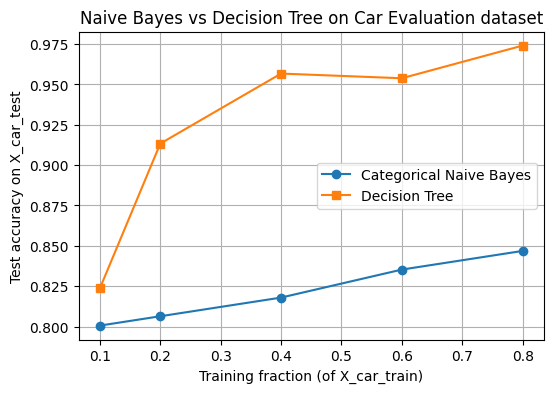

In [29]:
# 5.4 Learning curves: Naive Bayes vs Decision Tree as train size changes

# We will vary the fraction of the TRAINING set we actually use to fit each model.
# Naive Bayes uses categorical features (X_car_train / X_car_test); Decision Tree
# uses one-hot encoded features (X_car_train_enc / X_car_test_enc).
train_fractions = [0.1, 0.2, 0.4, 0.6, 0.8]

nb_accuracies = []  # Naive Bayes test accuracy for each train fraction
dt_accuracies = []  # Decision Tree test accuracy for each train fraction

for frac in train_fractions:
    # TODO: For each fraction, draw a stratified subsample from the training set,
    # fit both models on that subsample, and evaluate on the same test set.

    # Steps:
    # 1. Use train_test_split on (X_car_train, y_car_train) with train_size=frac,
    #    stratify=y_car_train, random_state=RANDOM_STATE to get a smaller training
    #    subset. To keep the same rows for both categorical and encoded data, subsample
    #    by index: e.g. split y_car_train.index by train_size=frac, then use .loc[idx]
    #    on X_car_train, X_car_train_enc, and y_car_train to get X_sub, X_sub_enc, y_sub.
    idx_sub, _ = train_test_split(
        y_car_train.index,
        train_size=frac,
        stratify=y_car_train,
        random_state=RANDOM_STATE
    )

    X_sub = X_car_train.loc[idx_sub]
    X_sub_enc = X_car_train_enc.loc[idx_sub]
    y_sub = y_car_train.loc[idx_sub]

    # 2. Fit MyCategoricalNaiveBayes(alpha=best_alpha_car) on (X_sub, y_sub); predict on X_car_test; append accuracy to nb_accuracies.
    nb_model = MyCategoricalNaiveBayes(alpha=best_alpha_car)
    nb_model.fit(X_sub, y_sub)

    y_nb_pred = nb_model.predict(X_car_test)
    nb_acc = accuracy_score(y_car_test, y_nb_pred)
    nb_accuracies.append(nb_acc)

    # 3. Fit DecisionTreeClassifier(random_state=RANDOM_STATE) on (X_sub_enc, y_sub);
    #    predict on X_car_test_enc; append accuracy to dt_accuracies.
    dt_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
    dt_model.fit(X_sub_enc, y_sub)

    y_dt_pred = dt_model.predict(X_car_test_enc)
    dt_acc = accuracy_score(y_car_test, y_dt_pred)
    dt_accuracies.append(dt_acc)

    # Hint (subsample by index so one subset works for both feature sets):
    #   idx_sub, _ = train_test_split(
    #       y_car_train.index, train_size=frac, stratify=y_car_train, random_state=RANDOM_STATE
    #   )
    #   X_sub = X_car_train.loc[idx_sub]
    #   X_sub_enc = X_car_train_enc.loc[idx_sub]
    #   y_sub = y_car_train.loc[idx_sub]

# After you fill in the loop and remove the 'pass', you can visualize the results:
plt.figure(figsize=(6, 4))
plt.plot(train_fractions, nb_accuracies, marker="o", label="Categorical Naive Bayes")
plt.plot(train_fractions, dt_accuracies, marker="s", label="Decision Tree")
plt.xlabel("Training fraction (of X_car_train)")
plt.ylabel("Test accuracy on X_car_test")
plt.title("Naive Bayes vs Decision Tree on Car Evaluation dataset")
plt.legend()
plt.grid(True)
plt.show()


## 6. Reflection Questions (20 pts)

Before exporting your notebook, briefly reflect on the following (you can add a short markdown or code cell with your answers).

1. **Tradeoffs in choosing \\(\\alpha\\):** What do you see as the main tradeoffs when picking a value for the smoothing parameter \\(\\alpha\\)? (Consider very small vs larger \\(\\alpha\\) in terms of overfitting, underfitting, and behavior with rare categories.) Did your cross-validation results match your intuition?

    A smaller alpha value keeps probability estimates close to the observed counts, which can improve accuracy when the dataset is large but may overfit rare categories. A larger alpha smooths probabilities toward a more uniform distribution. This reduces variance and stabilizes estimates for rare categories, but it can also weaken meaningful differences between feature levels and lead to underfitting. In my results, the smallest alpha performed best, suggesting that only minimal smoothing was needed. This makes sense because the feature levels in the Car dataset are evenly distributed and well represented in the data.

<br>

2. **\\(\\alpha\\) and training set size:** How do you expect a "good" choice of \\(\\alpha\\) to depend on the size of the training set? For example, with more data, would you lean toward a smaller or larger \\(\\alpha\\)? Does your experiment support that intuition?

    With more training data, probability estimates become more stable, so a smaller alpha is typically sufficient. With less data, a larger alpha can help prevent unstable estimates and overfitting. The best alpha for the Car dataset was 0.001, which suggests the training set was large enough to rely mostly on observed frequencies.

<br>

3. **Training set size: Naive Bayes vs Decision Tree:** In the learning-curve plot, how did test accuracy change with training fraction for Naive Bayes compared with the Decision Tree? Which model tended to benefit more from additional training data, and why might that be?

    As the training fraction increased, both models improved, but the Decision Tree improved more and consistently outperformed Naive Bayes. The Decision Tree benefited more from additional data because it can capture feature interactions and rule based structure present in the dataset. Even though there are only six predictors, the target `class` depends on combinations of these features, which the Decision Tree can model directly. In contrast, Naive Bayes assumes independence between features, so additional data did not improve performance as dramatically.

<br>

4. **When would you use each?** Based on this assignment, in what kinds of problems or data settings would you prefer (a) Naive Bayes with categorical features, and (b) a Decision Tree? What role did the number of features and the amount of training data play in your reasoning?

    Naive Bayes with categorical features is preferable in high dimensional settings with many features or limited data, where simplicity and fast training are important. Because it makes strong independence assumptions, it can perform well even when the sample size is relatively small. A Decision Tree is preferable when feature interactions are important and the dataset follows rule based patterns. In this assignment, the small number of features and the structured relationships between them favored the Decision Tree, especially with sufficient training data to learn accurate splits.

## 7. Convert Notebook to HTML (3 pts)

In [30]:
# Convert this notebook to HTML